# Canonical availability-model results

September 13 update. Generated from saved predictions; no training runs are triggered by this notebook. Sources: `results/canonical_availability/`. The availability-aware ablation sweep is running; its findings are not yet incorporated.


# Canonical availability models

q65, exact calendar t+3; sensor labels only. Mean ± sample SD over seeds 42/43/44. SD describes training variability, not sampling uncertainty.

| Model | Scope | N | Accuracy | ROC-AUC | WetF1 | DryPrecision | DryRecall | DryF1 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| LSTM | full_sensor | 956 | 0.954 ± 0.007 | 0.982 ± 0.005 | 0.971 ± 0.004 | 0.858 ± 0.026 | 0.919 ± 0.027 | 0.887 ± 0.016 |
| LSTM | headwater | 743 | 0.948 ± 0.009 | 0.979 ± 0.007 | 0.966 ± 0.006 | 0.856 ± 0.034 | 0.910 ± 0.024 | 0.882 ± 0.018 |
| LSTM | matched | 908 | 0.951 ± 0.007 | 0.981 ± 0.005 | 0.969 ± 0.005 | 0.858 ± 0.026 | 0.919 ± 0.027 | 0.887 ± 0.016 |
| LSTM | tailwater | 165 | 0.968 ± 0.003 | 0.987 ± 0.004 | 0.980 ± 0.002 | 0.870 ± 0.052 | 0.966 ± 0.060 | 0.913 ± 0.007 |
| RGCN | full_sensor | 908 | 0.964 ± 0.003 | 0.986 ± 0.001 | 0.977 ± 0.002 | 0.858 ± 0.014 | 0.989 ± 0.005 | 0.919 ± 0.006 |
| RGCN | headwater | 743 | 0.969 ± 0.001 | 0.985 ± 0.001 | 0.980 ± 0.001 | 0.881 ± 0.005 | 0.988 ± 0.006 | 0.931 ± 0.002 |
| RGCN | matched | 908 | 0.964 ± 0.003 | 0.986 ± 0.001 | 0.977 ± 0.002 | 0.858 ± 0.014 | 0.989 ± 0.005 | 0.919 ± 0.006 |
| RGCN | tailwater | 165 | 0.941 ± 0.015 | 0.991 ± 0.003 | 0.963 ± 0.010 | 0.752 ± 0.050 | 1.000 ± 0.000 | 0.858 ± 0.032 |


# Dry counts over sensor-observed validation dates

Canonical aggregation evaluation: availability-RGCN, q65, rolling exact-calendar t+3 forecasts. Only genuine sensor-labeled dates are counted. Each probability remains attached to its forecast target date; the latent AR(1) evolves across calendar gaps, but unobserved dates never enter the count. 10,000 simulations per reach. Observed count is the actual number of dry sensor dates, without annualization. Predicted expected count is the sum of date-specific dry probabilities.

Two setups: Platt calibration fitted on each model's own 579 training predictions with rho capped at 0.98; and raw probabilities with no cap. Rho is estimated from consecutive-day training sensor pairs; constant training series retain the existing rho=0 fallback. Seed 42 is the primary illustration, not selected by coverage.

| seed | method | reaches | n_observed | included | mean_interval_width | mean_absolute_count_error |
| --- | --- | --- | --- | --- | --- | --- |
| 42 | platt_rho98 | 22 | 908 | 22 | 4.182 | 1.383 |
| 42 | raw_unclipped | 22 | 908 | 18 | 5.773 | 2.992 |
| 43 | platt_rho98 | 22 | 908 | 21 | 6.545 | 0.935 |
| 43 | raw_unclipped | 22 | 908 | 15 | 6.682 | 3.236 |
| 44 | platt_rho98 | 22 | 908 | 20 | 3.864 | 1.377 |
| 44 | raw_unclipped | 22 | 908 | 19 | 6.000 | 2.116 |

## Interpretation

Intervals summarize rolling forecasts retrospectively; later issue dates can use observations acquired during validation. They are not a whole-period forecast issued on September 10. This limitation ALSO applied to the former 365-day setup: it bootstrapped these same rolling validation probabilities rather than forecasting a year from a single issue date. These conditional simulation intervals do not include parameter or calibration uncertainty; the binary-series correlation is used approximately as the latent Gaussian AR coefficient. Inclusion across 22 reaches is a descriptive diagnostic.

## Seed-42 reach counts

| seed | method | site | n_observed | first_date | last_date | calendar_span | observed_dry | expected_dry | simulation_mean | lo | hi | included | rho | rho_used | rho_pairs |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 42 | platt_rho98 | 55000900029021 | 40 | 2020-09-11 | 2020-10-20 | 40 | 0 | 0.217 | 0.218 | 0.000 | 1.000 | True | 0.000 | 0.000 | 84 |
| 42 | platt_rho98 | 55000900030173 | 43 | 2020-09-11 | 2020-10-23 | 43 | 0 | 0.239 | 0.241 | 0.000 | 2.000 | True | 0.000 | 0.000 | 77 |
| 42 | platt_rho98 | 55000900096564 | 36 | 2020-09-11 | 2020-10-28 | 48 | 1 | 0.737 | 0.727 | 0.000 | 3.000 | True | 0.000 | 0.000 | 66 |
| 42 | platt_rho98 | 55000900097164 | 41 | 2020-09-11 | 2020-10-22 | 42 | 29 | 39.310 | 39.326 | 27.000 | 41.000 | True | 1.000 | 0.980 | 83 |
| 42 | platt_rho98 | 55000900097169 | 42 | 2020-09-11 | 2020-10-22 | 42 | 35 | 41.164 | 41.102 | 29.000 | 42.000 | True | 1.000 | 0.980 | 74 |
| 42 | platt_rho98 | 55000900097170 | 48 | 2020-09-11 | 2020-10-29 | 49 | 46 | 46.830 | 46.902 | 34.000 | 48.000 | True | 1.000 | 0.980 | 81 |
| 42 | platt_rho98 | 55000900099610 | 39 | 2020-09-11 | 2020-10-20 | 40 | 0 | 0.191 | 0.189 | 0.000 | 1.000 | True | 0.000 | 0.000 | 75 |
| 42 | platt_rho98 | 55000900100137 | 40 | 2020-09-11 | 2020-10-21 | 41 | 36 | 39.029 | 38.975 | 27.000 | 40.000 | True | 1.000 | 0.980 | 69 |
| 42 | platt_rho98 | 55000900131558 | 42 | 2020-09-11 | 2020-10-22 | 42 | 0 | 0.238 | 0.238 | 0.000 | 1.000 | True | 0.000 | 0.000 | 79 |
| 42 | platt_rho98 | 55000900167054 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 0.189 | 0.193 | 0.000 | 1.000 | True | 0.000 | 0.000 | 73 |
| 42 | platt_rho98 | 55000900167692 | 35 | 2020-09-11 | 2020-10-20 | 40 | 0 | 2.267 | 2.262 | 0.000 | 5.000 | True | 0.000 | 0.000 | 80 |
| 42 | platt_rho98 | 55000900167704 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 0.194 | 0.197 | 0.000 | 1.000 | True | 0.000 | 0.000 | 84 |
| 42 | platt_rho98 | 55000900201800 | 41 | 2020-09-11 | 2020-10-22 | 42 | 0 | 0.195 | 0.198 | 0.000 | 1.000 | True | 0.000 | 0.000 | 74 |
| 42 | platt_rho98 | 55000900201811 | 43 | 2020-09-11 | 2020-10-23 | 43 | 0 | 0.180 | 0.183 | 0.000 | 1.000 | True | 0.000 | 0.000 | 84 |
| 42 | platt_rho98 | 55000900202948 | 43 | 2020-09-11 | 2020-10-23 | 43 | 0 | 0.188 | 0.190 | 0.000 | 1.000 | True | 0.000 | 0.000 | 77 |
| 42 | platt_rho98 | 55000900235848 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 0.167 | 0.165 | 0.000 | 1.000 | True | 0.000 | 0.000 | 84 |
| 42 | platt_rho98 | 55000900236525 | 40 | 2020-09-11 | 2020-10-20 | 40 | 0 | 0.216 | 0.216 | 0.000 | 1.000 | True | 0.000 | 0.000 | 84 |
| 42 | platt_rho98 | 55000900237668 | 48 | 2020-09-11 | 2020-10-28 | 48 | 42 | 46.362 | 46.380 | 36.000 | 48.000 | True | 0.927 | 0.927 | 64 |
| 42 | platt_rho98 | 55000900271029 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 0.230 | 0.231 | 0.000 | 1.000 | True | 0.000 | 0.000 | 84 |
| 42 | platt_rho98 | 55000900271635 | 42 | 2020-09-11 | 2020-10-22 | 42 | 0 | 0.288 | 0.289 | 0.000 | 2.000 | True | 0.000 | 0.000 | 77 |
| 42 | platt_rho98 | 55000900272209 | 40 | 2020-09-11 | 2020-10-20 | 40 | 0 | 0.272 | 0.282 | 0.000 | 2.000 | True | 0.000 | 0.000 | 80 |
| 42 | platt_rho98 | 55000900272714 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 0.197 | 0.194 | 0.000 | 1.000 | True | 0.000 | 0.000 | 78 |
| 42 | raw_unclipped | 55000900029021 | 40 | 2020-09-11 | 2020-10-20 | 40 | 0 | 2.059 | 2.058 | 0.000 | 5.000 | True | 0.000 | 0.000 | 84 |
| 42 | raw_unclipped | 55000900030173 | 43 | 2020-09-11 | 2020-10-23 | 43 | 0 | 2.310 | 2.327 | 0.000 | 6.000 | True | 0.000 | 0.000 | 77 |
| 42 | raw_unclipped | 55000900096564 | 36 | 2020-09-11 | 2020-10-28 | 48 | 1 | 5.723 | 5.686 | 2.000 | 10.000 | False | 0.000 | 0.000 | 66 |
| 42 | raw_unclipped | 55000900097164 | 41 | 2020-09-11 | 2020-10-22 | 42 | 29 | 39.658 | 39.627 | 33.000 | 41.000 | False | 1.000 | 1.000 | 83 |
| 42 | raw_unclipped | 55000900097169 | 42 | 2020-09-11 | 2020-10-22 | 42 | 35 | 41.750 | 41.757 | 37.000 | 42.000 | False | 1.000 | 1.000 | 74 |
| 42 | raw_unclipped | 55000900097170 | 48 | 2020-09-11 | 2020-10-29 | 49 | 46 | 46.988 | 47.034 | 39.000 | 48.000 | True | 1.000 | 1.000 | 81 |
| 42 | raw_unclipped | 55000900099610 | 39 | 2020-09-11 | 2020-10-20 | 40 | 0 | 1.448 | 1.437 | 0.000 | 4.000 | True | 0.000 | 0.000 | 75 |
| 42 | raw_unclipped | 55000900100137 | 40 | 2020-09-11 | 2020-10-21 | 41 | 36 | 39.308 | 39.296 | 34.000 | 40.000 | True | 1.000 | 1.000 | 69 |
| 42 | raw_unclipped | 55000900131558 | 42 | 2020-09-11 | 2020-10-22 | 42 | 0 | 2.381 | 2.369 | 0.000 | 6.000 | True | 0.000 | 0.000 | 79 |
| 42 | raw_unclipped | 55000900167054 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 1.445 | 1.445 | 0.000 | 4.000 | True | 0.000 | 0.000 | 73 |
| 42 | raw_unclipped | 55000900167692 | 35 | 2020-09-11 | 2020-10-20 | 40 | 0 | 7.098 | 7.108 | 3.000 | 12.000 | False | 0.000 | 0.000 | 80 |
| 42 | raw_unclipped | 55000900167704 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 1.552 | 1.553 | 0.000 | 4.000 | True | 0.000 | 0.000 | 84 |
| 42 | raw_unclipped | 55000900201800 | 41 | 2020-09-11 | 2020-10-22 | 42 | 0 | 1.505 | 1.491 | 0.000 | 4.000 | True | 0.000 | 0.000 | 74 |
| 42 | raw_unclipped | 55000900201811 | 43 | 2020-09-11 | 2020-10-23 | 43 | 0 | 1.119 | 1.113 | 0.000 | 4.000 | True | 0.000 | 0.000 | 84 |
| 42 | raw_unclipped | 55000900202948 | 43 | 2020-09-11 | 2020-10-23 | 43 | 0 | 1.289 | 1.286 | 0.000 | 4.000 | True | 0.000 | 0.000 | 77 |
| 42 | raw_unclipped | 55000900235848 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 0.931 | 0.926 | 0.000 | 3.000 | True | 0.000 | 0.000 | 84 |
| 42 | raw_unclipped | 55000900236525 | 40 | 2020-09-11 | 2020-10-20 | 40 | 0 | 2.051 | 2.039 | 0.000 | 5.000 | True | 0.000 | 0.000 | 84 |
| 42 | raw_unclipped | 55000900237668 | 48 | 2020-09-11 | 2020-10-28 | 48 | 42 | 46.313 | 46.299 | 37.000 | 48.000 | True | 0.927 | 0.927 | 64 |
| 42 | raw_unclipped | 55000900271029 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 2.235 | 2.218 | 0.000 | 5.000 | True | 0.000 | 0.000 | 84 |
| 42 | raw_unclipped | 55000900271635 | 42 | 2020-09-11 | 2020-10-22 | 42 | 0 | 3.080 | 3.076 | 0.000 | 7.000 | True | 0.000 | 0.000 | 77 |
| 42 | raw_unclipped | 55000900272209 | 40 | 2020-09-11 | 2020-10-20 | 40 | 0 | 2.974 | 2.969 | 0.000 | 6.000 | True | 0.000 | 0.000 | 80 |
| 42 | raw_unclipped | 55000900272714 | 41 | 2020-09-11 | 2020-10-21 | 41 | 0 | 1.600 | 1.605 | 0.000 | 4.000 | True | 0.000 | 0.000 | 78 |


# LSTM feature importance

Seed 42, 956 sensor targets. Five sequence-level permutations per feature, measured by decrease in accuracy. Saved checkpoint predictions reproduced before scoring. Signed values are retained in CSV; negative decreases are clipped to zero only for the max-scaled figure. Correlated inputs and overlapping sequences limit causal interpretation.


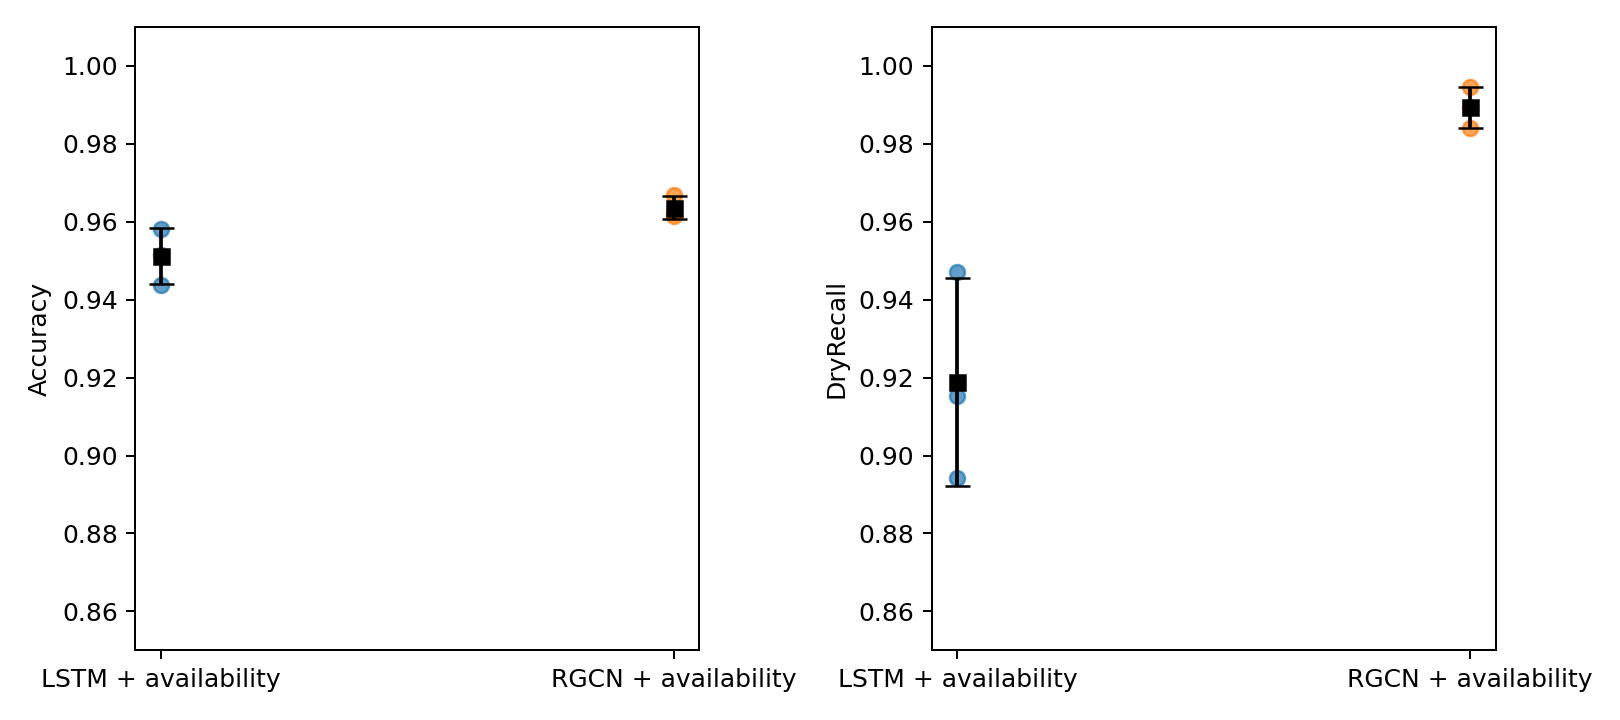

In [5]:
from IPython.display import Image, display
display(Image(filename="results/canonical_availability/classification_seeds.png"))

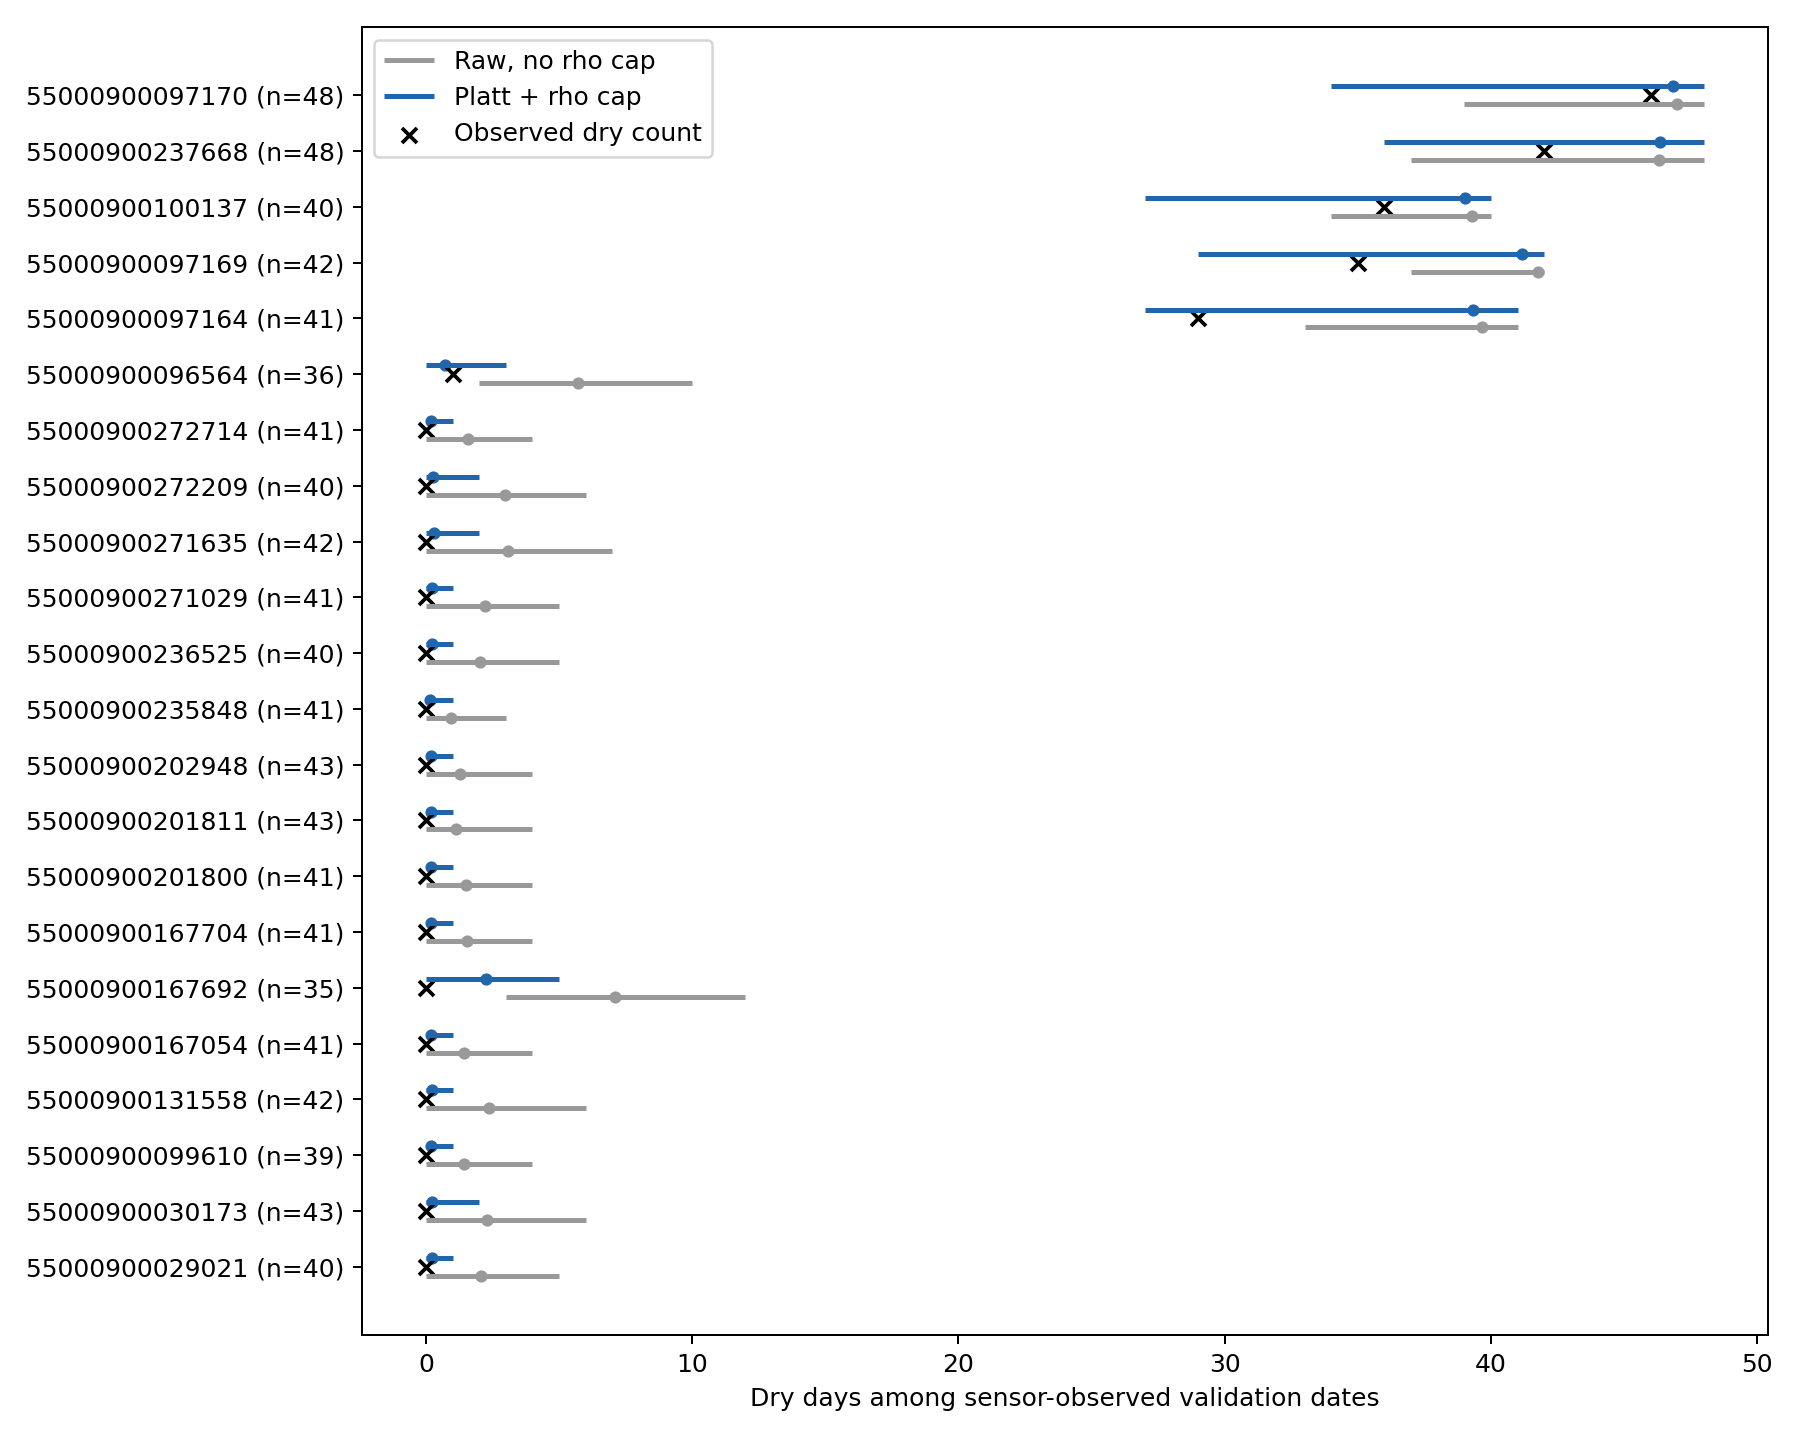

In [6]:
from IPython.display import Image, display
display(Image(filename="results/canonical_availability/observed_copula_intervals.png"))

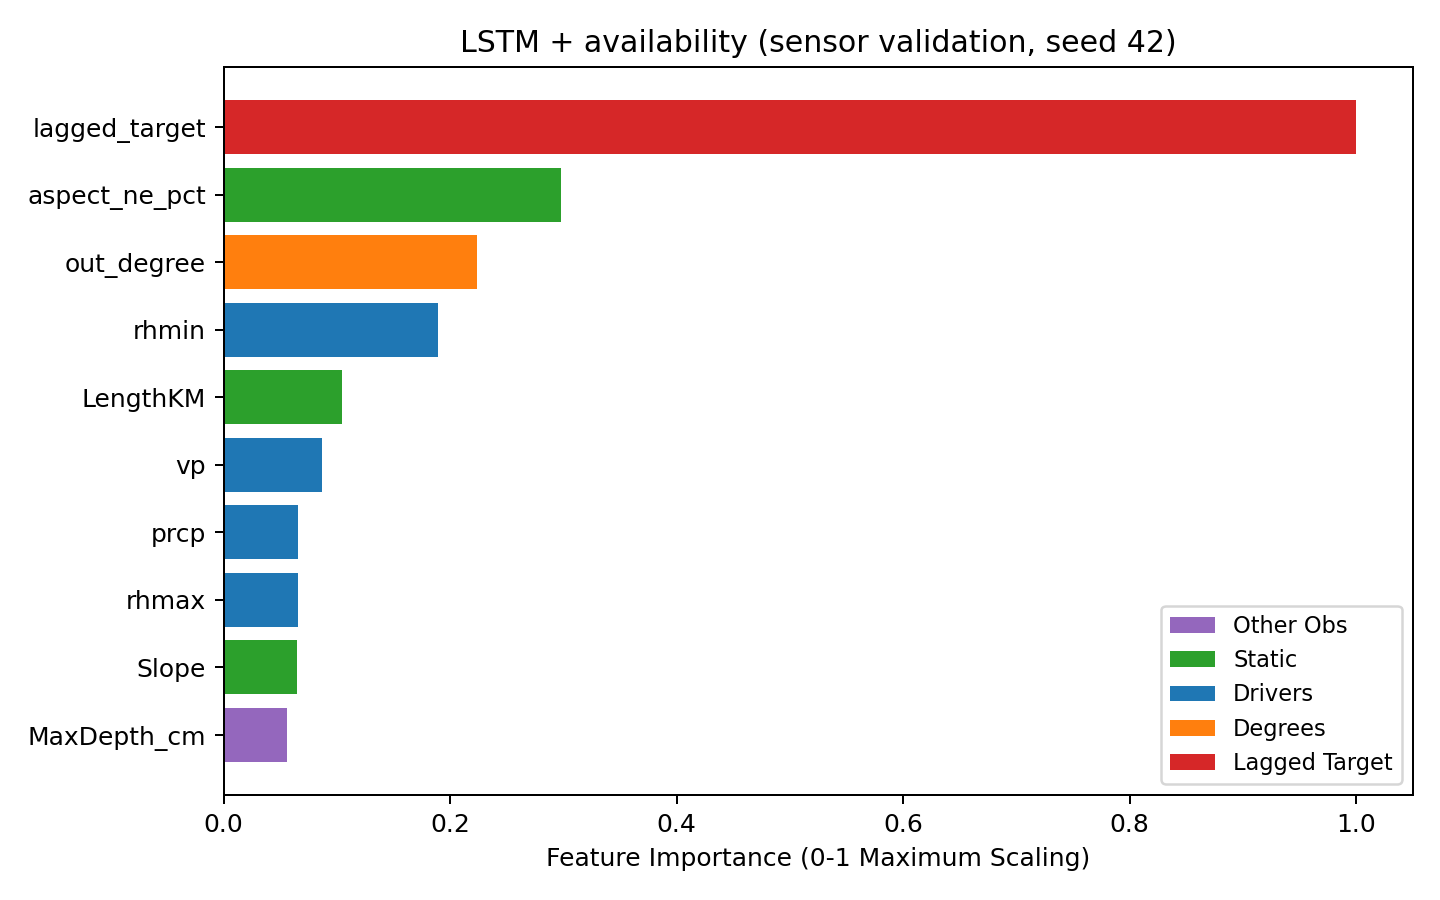

In [7]:
from IPython.display import Image, display
display(Image(filename="results/canonical_availability/figure3d_lstm_availability.png"))